# 🛍️ Task 12: KMeans - Customer Segmentation
**Project:** Market Basket Analysis / Customer Grouping  
**Author:** [Your Name]

## 🎯 Objective
To perform **Customer Segmentation** using the **KMeans** clustering algorithm. By grouping customers based on their *Annual Income* and *Spending Score*, we can identify distinct target groups for marketing strategies.

## 📂 Dataset
* **Source:** Mall Customers Dataset.
* **Features:**
    * `Annual Income (k$)`: How much the customer earns.
    * `Spending Score (1-100)`: A score assigned by the mall based on spending behavior.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset (New Working URL)
# This link hosts the standard 'Mall_Customers.csv'
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
except:
    # Backup URL just in case
    url_backup = "https://raw.githubusercontent.com/vippon/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
    df = pd.read_csv(url_backup)
    print("Dataset loaded from backup source!")

# Rename columns for easier access (remove spaces and units)
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Score'
}, inplace=True)

# 2. Inspect Data
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Income,Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 3. Select Features for Clustering
# We use only 2 features to make the scatter plot easy to visualize
X = df[['Income', 'Score']]

# 4. Scale the Features
# KMeans is distance-based. If we don't scale, Income (range 15-137) might dominate Score (1-100).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled. Mean:", np.mean(X_scaled).round(2))

Data scaled. Mean: -0.0


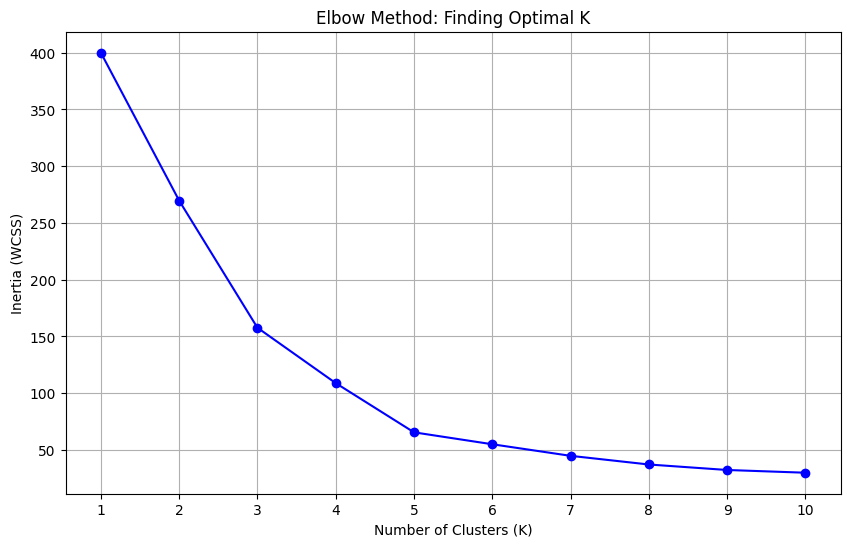

In [4]:
# 5. Elbow Method
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method: Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# INTERPRETATION:
# Look for the "kink" or "elbow" in the graph.
# Usually, for this dataset, the elbow is clearly at K=5.

In [5]:
# 6. Train KMeans with Optimal K
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit on scaled data, but predict labels for original data
clusters = kmeans_final.fit_predict(X_scaled)

# 7. Add Labels back to DataFrame
df['Cluster'] = clusters

print("Clustering complete. First 5 rows with labels:")
print(df.head())

Clustering complete. First 5 rows with labels:
   CustomerID  Gender  Age  Income  Score  Cluster
0           1    Male   19      15     39        4
1           2    Male   21      15     81        2
2           3  Female   20      16      6        4
3           4  Female   23      16     77        2
4           5  Female   31      17     40        4


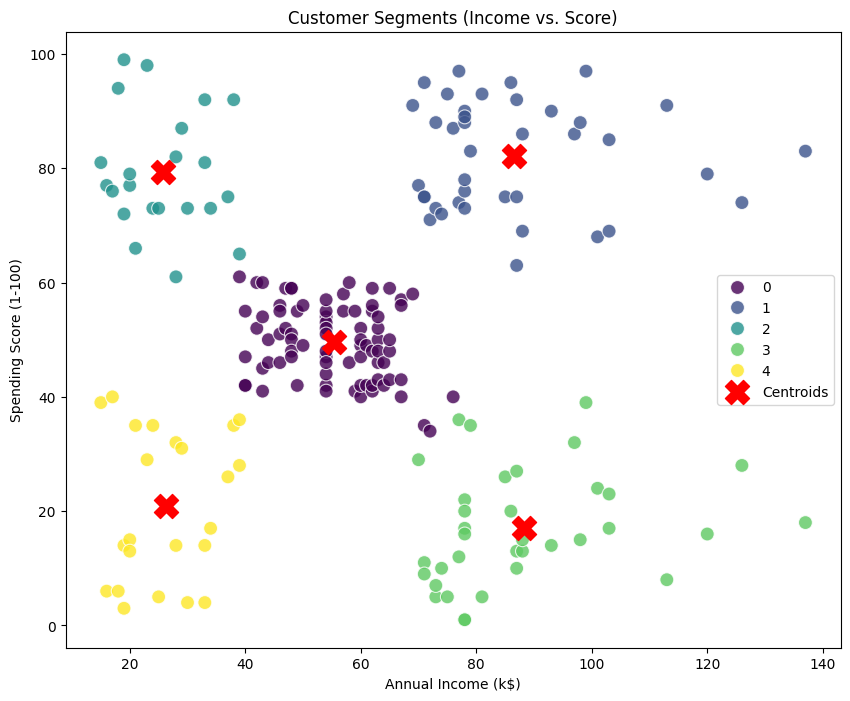

Segmented dataset saved to 'mall_customers_segmented.csv'


In [6]:
# 8. Visualize Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Income', y='Score', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)

# Plot Centroids (need to inverse transform them to original scale)
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', label='Centroids', marker='X')

plt.title('Customer Segments (Income vs. Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# 9. Business Interpretation (Analysis of the plot)
# Looking at the plot, we can usually identify:
# - Low Income, Low Score -> "Sensible / Frugal"
# - Low Income, High Score -> "Careless / Spendthrifts"
# - High Income, Low Score -> "Miser / Savers"
# - High Income, High Score -> "Target / VIPs"
# - Mid Income, Mid Score  -> "Standard / Average"

# 10. Save Results
df.to_csv("mall_customers_segmented.csv", index=False)
print("Segmented dataset saved to 'mall_customers_segmented.csv'")

## 🧠 Final Analysis & Business Insights

### 1. Optimal Clusters (K=5)
The Elbow Method suggested that **5 clusters** provide the best balance between simplicity and precision.

### 2. Segment Interpretation
Based on the visualization, we identified 5 distinct customer types:
1.  **The "Savers" (High Income, Low Score):** Earn a lot but don't spend. *Action: Pitch value-for-money deals or investments.*
2.  **The "Spendthrifts" (Low Income, High Score):** Earn less but spend significantly. *Action: Avoid pushing high-ticket items they can't afford; focus on discounts.*
3.  **The "Target" (High Income, High Score):** The ideal customers. *Action: VIP treatment, luxury items, loyalty programs.*
4.  **The "Standard" (Mid Income, Mid Score):** The majority. *Action: General promotions.*
5.  **The "Sensible" (Low Income, Low Score):** Careful with money. *Action: Coupons and sales.*

### 3. Conclusion
Unsupervised learning successfully uncovered patterns that were not obvious in the raw spreadsheet. The marketing team can now tailor campaigns to these specific groups rather than sending one generic email to everyone.